# Deep Learning Project - Classifier

Group 4 formed by:
- Daniel Carneiro (up202108832)
- David Pinto (up201704300)
- José Santos (up202108729)

This assignment is separated into two parts.

- Classifier Model
- Generative Model

The dataset to be used is the DeepFakeFace dataset obtained through [huggingface](https://huggingface.co/datasets/OpenRL/DeepFakeFace).

We devide the Classifier Notebook in two notebooks (Creation Model, Model Comparison), this Notebook we will focus on its Comparison. 

## Imports and Global Setup

In [29]:
import json
from datasets import load_from_disk, load_dataset
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pandas.plotting import table
import pandas as pd

def ensure_three_channels(image):
    """
    Convert all images to 3-channel format.
    - If the image is grayscale (1 channel), convert it to RGB (3 channels).
    - If it's already RGB, keep it unchanged.
    """
    if image.mode != "RGB":  # Check if the image is not already RGB
        image = image.convert("RGB")  # Convert grayscale (1 channel) to RGB (3 channels)
    return image

# Define a transformation
transform_normal = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_grayscale = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_contrast = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.ColorJitter(contrast=20), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_saturation = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.ColorJitter(saturation=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_gaussianBlur = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.GaussianBlur(kernel_size=(31,31)),  # Convert to 3-channel grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_pixelation = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224//8 , 224//8), interpolation=Image.NEAREST),  # Downscale
    transforms.Resize((224, 224), interpolation=Image.NEAREST), # Resize to match CNN input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
save_models_dir = "./models/"
save_dataset_dir = "./dataset/"
colors = {
    "resnet_normal": "blue",
    "resnet_grayscale": "green",
    "resnet_constrast": "red",
    "resnet_gaussianblur": "purple",
    "resnet_saturation": "orange",
    "resnet_pixelation": "brown",
    "CNN_dropout_normal": "pink",
    "CNN_dropout_grayscale": "cyan",
    "CNN_dropout_contrast": "magenta",
    "CNN_dropout_gaussianblur": "yellow",
    "CNN_dropout_saturation": "gray",
    "CNN_dropout_pixelation": "teal",
    "CNN_simple_normal": "lightblue",
    "CNN_simple_grayscale": "lime",
    "CNN_simple_contrast": "indigo",
    "CNN_simple_gaussianblur": "violet",
    "CNN_simple_saturation": "salmon",
    "CNN_simple_pixelation": "gold"
}
results = {}

## Data Loading & Exploration Data Analysis

In this section, we will load the dataset and perform some basic data exploration and visualization.
The dataset has 120000 images of which:
- Real Images (30000):
    - Wiki (30000)
- Fake Images (90000):
    - Stable Diffusion v1.5 (30000)
    - Stable Diffusion Inpainting (30000)
    - Insight (30000)

In [8]:
try:
    dataset = load_from_disk("./dataset")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Dataset not found. Trying to download and save him")
    dataset = load_dataset("OpenRL/DeepFakeFace")
    dataset.save_to_disk(save_dataset_dir) 
print(dataset)

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 120004
    })
})


In [9]:
with open('./results.json', 'r') as file:
    results = json.load(file)

## Analize

As mentioned previously, we evaluated the models with the metrics Area Under Curve (AUC), Equal Error Rate (ERR) and Accuracy (Acc). However, before we start analyzing them, we think we should mention the evolution of the loss reward that we decided to use (nn.CrossEntropyLoss()). As we can see, all models tend to decrease the loss as the epochs occur. In this way, we can see that the models are managing to learn something over time.

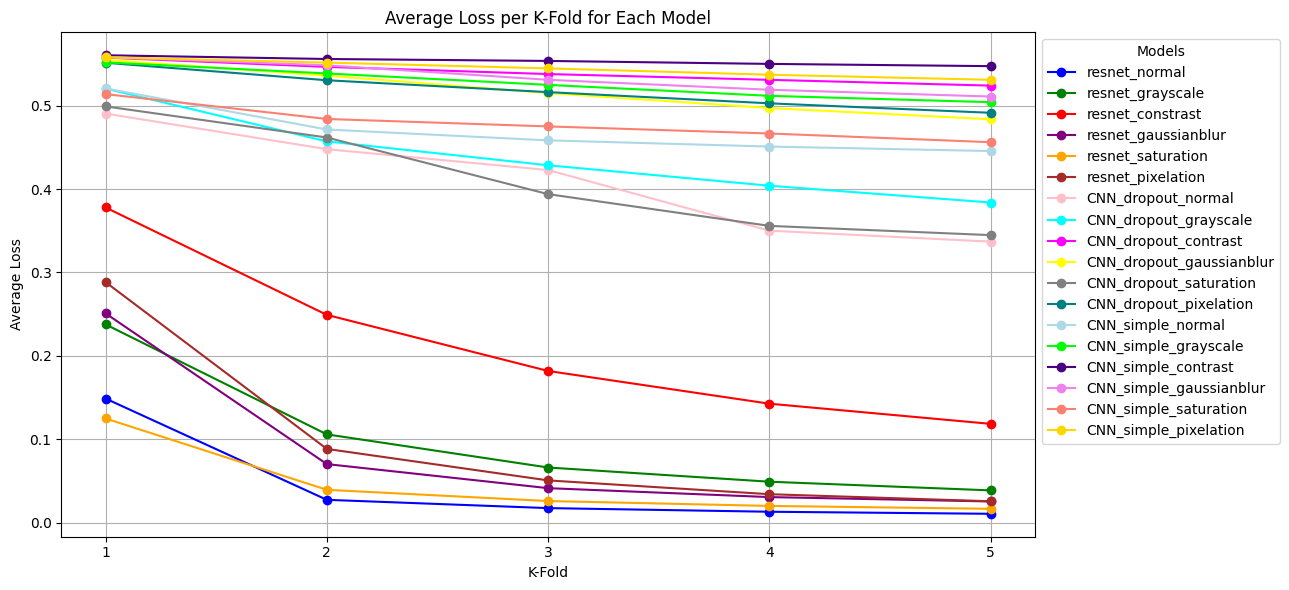

In [ ]:
plt.figure(figsize=(13, 6))

# Loop over models
for model_name, model in results.items():
    kfolds_data = model["kfolds"]
    avg_losses_per_kfold = []
    
    # Calculate average loss per kfold
    for fold, data in kfolds_data.items():
        fold_losses = [float(data[str(i)]["loss"]) for i in range(5)]
        avg_loss = np.mean(fold_losses)
        avg_losses_per_kfold.append(avg_loss)
    
    # Select color for the model
    color = colors.get(model_name, "black")  # Default to black if no color is specified
    plt.plot(range(1, 6), avg_losses_per_kfold, marker='o', label=model_name, color=color)

# Customize the plot
plt.title("Average Loss per K-Fold for Each Model")
plt.xlabel("K-Fold")
plt.ylabel("Average Loss")
plt.xticks(range(1, 6))
plt.grid(True)

# Adjust the legend to be on the right side
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Models")

# Adjust layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()


Now moving on to the metrics themselves, we can observe the accuracy, AUC and EER respectively, in them we can observe that the accuracy and AUC increase over time and that the EER decreases, this happens especially in the resnet models, perhaps because we
have already used a model with pre-trained weights the result was better.

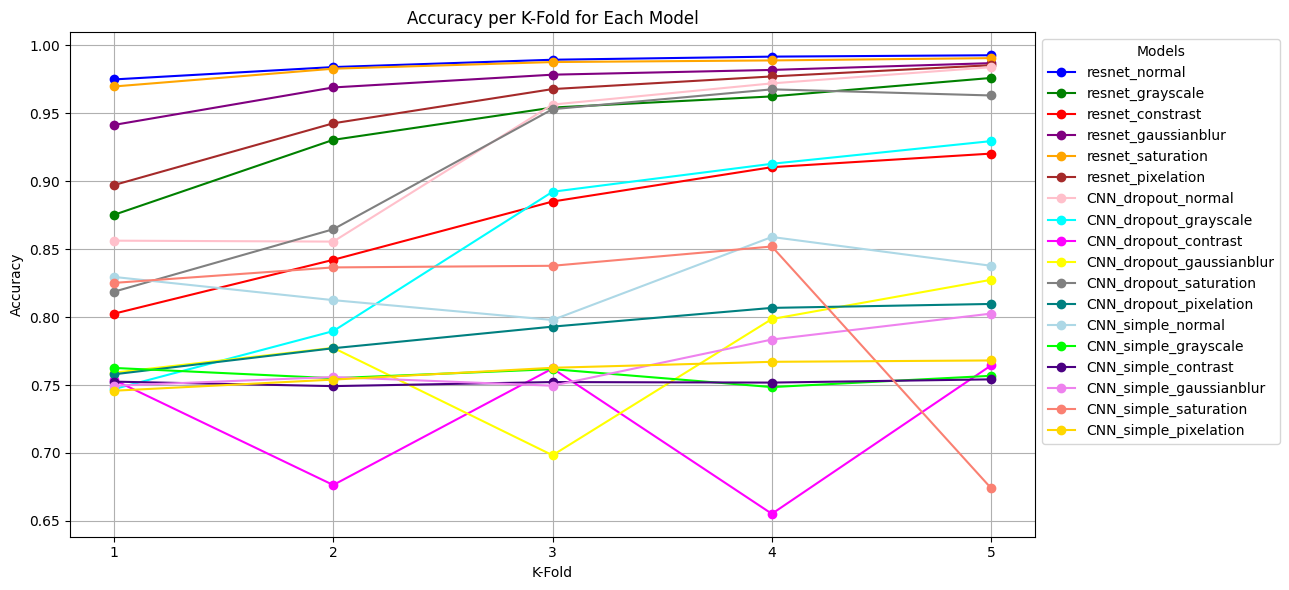

In [ ]:
plt.figure(figsize=(13, 6))

for model_name, model in results.items():
    kfolds_data = model["kfolds"]
    accuracy_per_kfold = []
    for fold, data in kfolds_data.items():
        accuracy = np.float64(data['Accuracy'])
        accuracy_per_kfold.append(accuracy)
    color = colors.get(model_name, "black")  # Default to black if no color is specified
    plt.plot(range(1, 6), accuracy_per_kfold, marker='o', label=model_name, color=color)

# Customize the plot
plt.title("Accuracy per K-Fold for Each Model")
plt.xlabel("K-Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.grid(True)

# Adjust the legend to be on the right side
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Models")

# Adjust layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

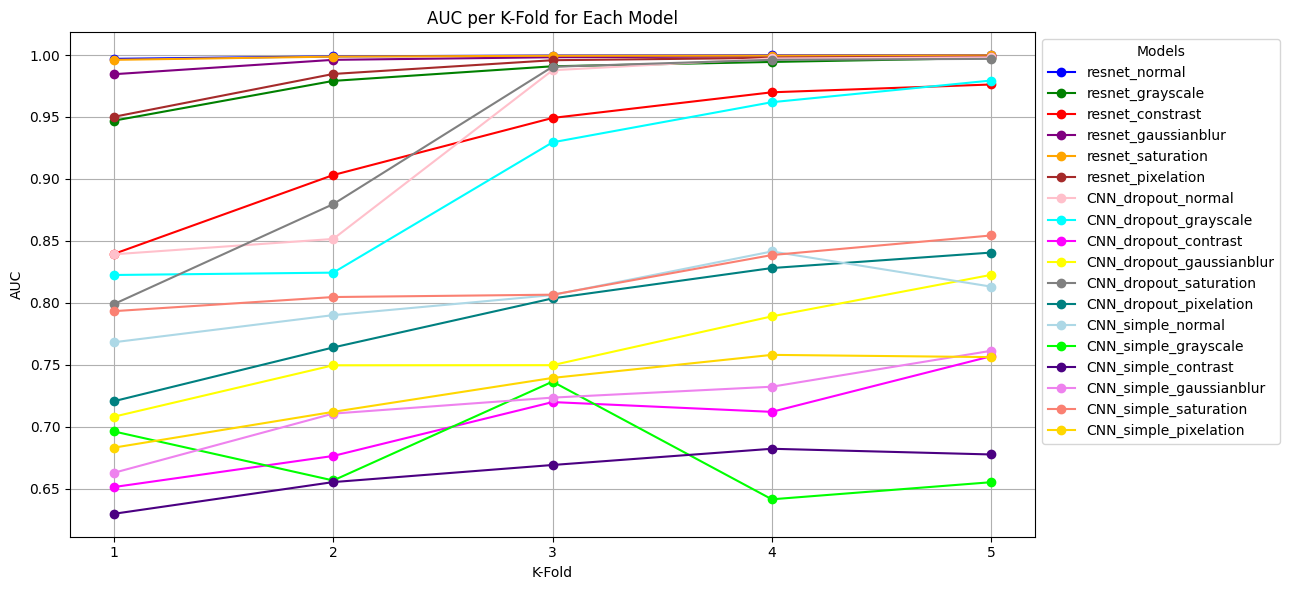

In [ ]:
plt.figure(figsize=(13, 6))

for model_name, model in results.items():
    kfolds_data = model["kfolds"]
    auc_per_kfold = []
    for fold, data in kfolds_data.items():
        auc = np.float64(data['AUC'])
        auc_per_kfold.append(auc)
    color = colors.get(model_name, "black")  # Default to black if no color is specified
    plt.plot(range(1, 6), auc_per_kfold, marker='o', label=model_name, color=color)

# Customize the plot
plt.title("AUC per K-Fold for Each Model")
plt.xlabel("K-Fold")
plt.ylabel("AUC")
plt.xticks(range(1, 6))
plt.grid(True)

# Adjust the legend to be on the right side
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Models")

# Adjust layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

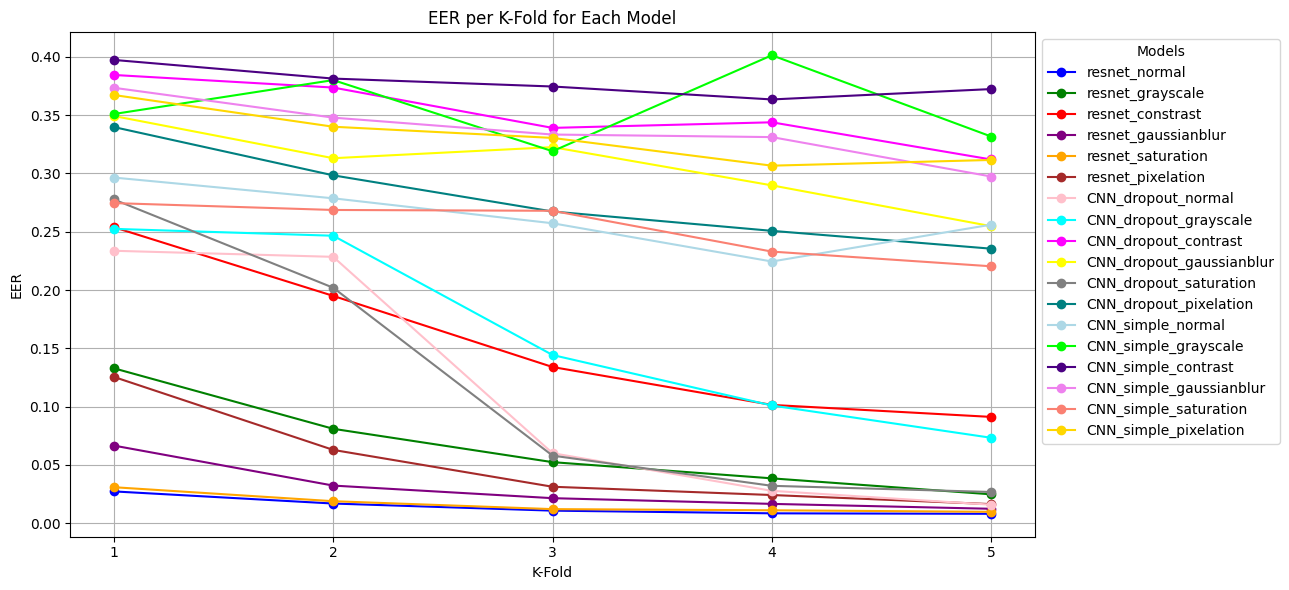

In [ ]:
plt.figure(figsize=(13, 6))

for model_name, model in results.items():
    kfolds_data = model["kfolds"]
    eer_per_kfold = []
    for fold, data in kfolds_data.items():
        eer = np.float64(data['EER'])
        eer_per_kfold.append(eer)
    color = colors.get(model_name, "black")  # Default to black if no color is specified
    plt.plot(range(1, 6), eer_per_kfold, marker='o', label=model_name, color=color)

# Customize the plot
plt.title("EER per K-Fold for Each Model")
plt.xlabel("K-Fold")
plt.ylabel("EER")
plt.xticks(range(1, 6))
plt.grid(True)

# Adjust the legend to be on the right side
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Models")

# Adjust layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

After verifying the excellent results of RESNET, we decided
to create our own neural network to see if we could achieve
equally good results. Although our first model (CNN simple)
performed poorly, after some research we discovered that
we could use dropout to turn off some connections and
make the model less prone to overfitting. We also decided
to add two more layers so that the model could achieve
more complex patterns.The result was a model that surprised
us (CNN dropout normal), with a few epochs the model
managed to achieve an impressive 92.5% accuracy and 93%
AUC, which means that the model was able to recognize
the differences between real and fake images well. having a
10% improvement in accuracy and 13% in AUC compared
to CNN simple normal (simple model that uses the untreated
dataset). Finally, after comparing these 3 models, we decided
to apply some pre-processing to the images to check if this
would impact the model’s learning. From the 6 datasets we
used, only the normal and saturated ones produced good
results compared to the others as you can see in the table.

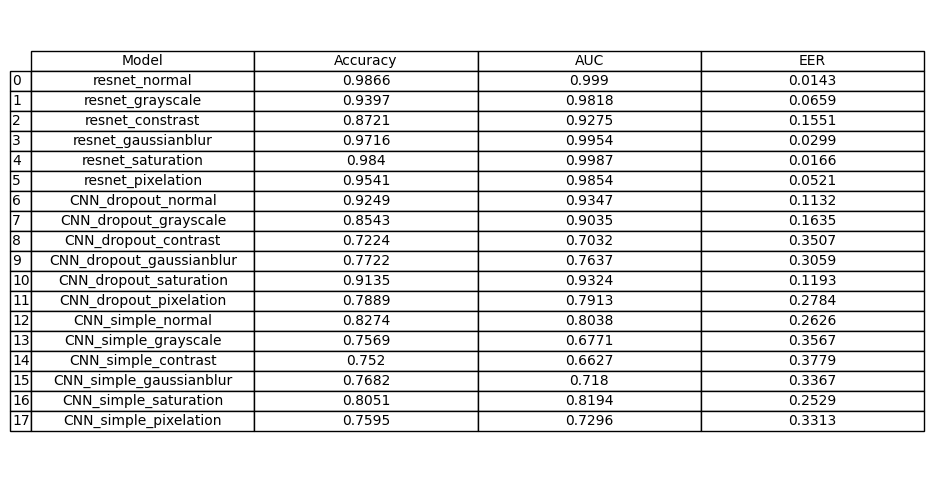

In [42]:
data = []

for model_name, model in results.items():
    # Extract the values from the dictionary and convert to float
    accuracy = float(model["Avg_Accuracy"])
    auc = float(model["Avg_AUC"])
    eer = float(model["Avg_EER"])

    # Append the data for this model to the list
    data.append([model_name, accuracy, auc, eer])

# Create a DataFrame using the collected data
df = pd.DataFrame(data, columns=["Model", "Accuracy", "AUC", "EER"])

# Create a plot for the table
fig, ax = plt.subplots(figsize=(12, 6))  # Adjust the size as needed

# Hide axes as we're only displaying the table
ax.axis('off')

# Display the table
tbl = table(ax, df, loc='center', cellLoc='center', colWidths=[0.2]*len(df.columns))

# Customize the table appearance
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)  # Adjust the scale for better readability

# Show the plot with the table
plt.show()